In [1]:
#importing the neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [98]:
df=pd.read_csv('raw_weekly_hospital_respiratory_data_2020_2024.csv')

In [99]:
df.head()

,Week Ending Date,Geographic aggregation,Number of Inpatient Beds,Number of Adult Inpatient Beds,Number of Pediatric Inpatient beds,Number of Inpatient Beds Occupied,Number of Adult Inpatient Beds Occupied,Number of Pediatric Inpatient Beds Occupied,Number of ICU Beds,Number of Adult ICU Beds,...,Absolute Change in the Percent Hospitals Reporting Adult RSV Admissions from Prior Week,Absolute Change in the Percent Hospitals Reporting RSV Admissions from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent Inpatient Beds Occupied from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent ICU Beds Occupied from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent Inpatient Beds Occupied by COVID-19 Patients from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent Inpatient Beds Occupied by Influenza Patients from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent Inpatient Beds Occupied by RSV Patients from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent ICU Beds Occupied by COVID-19 Patients from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent ICU Beds Occupied by Influenza Patients from Prior Week,Absolute Change in the Percent Hospitals Reporting Percent ICU Beds Occupied by RSV Patients from Prior Week
0,2023-08-12,WA,10650.0,9282.0,482.0,9040.0,8117.0,339.0,1623.0,1059.0,...,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0
1,2023-08-12,WI,10752.0,9824.0,425.0,7574.0,7027.0,286.0,1566.0,1232.0,...,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0
2,2023-08-12,WV,4813.0,4556.0,256.0,3701.0,3562.0,139.0,639.0,595.0,...,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0
3,2023-08-12,WY,1318.0,1142.0,25.0,559.0,534.0,6.0,114.0,109.0,...,0.0,0.0,0.03,0.03,0.03,0.03,0.0,0.03,0.03,0.0
4,2023-08-19,AK,1354.0,1192.0,77.0,1054.0,939.0,43.0,184.0,126.0,...,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.0


In [100]:
#Convert Week Ending Date to datetime and set as index:

# Convert to datetime, rename, and set index
df['Week Ending Date'] = pd.to_datetime(df['Week Ending Date'])
df.rename(columns={'Week Ending Date':'week_ending_date'}, inplace=True)
df.set_index('week_ending_date', inplace=True)

# Confirm
print(df.index)




DatetimeIndex(['2023-08-12', '2023-08-12', '2023-08-12', '2023-08-12',
               '2023-08-19', '2023-08-19', '2023-08-19', '2023-08-19',
               '2023-08-19', '2023-08-19',
               ...
               '2023-08-12', '2023-08-12', '2023-08-12', '2023-08-12',
               '2023-08-12', '2023-08-12', '2023-08-12', '2023-08-12',
               '2023-08-12', '2023-08-12'],
              dtype='datetime64[ns]', name='week_ending_date', length=12768, freq=None)


In [101]:
#Ensure numeric columns are numeric:
numeric_cols=df.columns[2:]
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [102]:
#inspect for missing values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12768 entries, 2023-08-12 to 2023-08-12
Columns: 156 entries, Geographic aggregation to Absolute Change in the Percent Hospitals Reporting Percent ICU Beds Occupied by RSV Patients from Prior Week
dtypes: float64(155), object(1)
memory usage: 15.3+ MB


Geographic aggregation                                                                                                        0
Number of Inpatient Beds                                                                                                    247
Number of Adult Inpatient Beds                                                                                              262
Number of Pediatric Inpatient beds                                                                                          283
Number of Inpatient Beds Occupied                                                                                           247
                                                                                                                           ... 
Absolute Change in the Percent Hospitals Reporting Percent Inpatient Beds Occupied by Influenza Patients from Prior Week     57
Absolute Change in the Percent Hospitals Reporting Percent Inpatient Beds Occupied by RSV Patients from 

In [103]:
# Convert all column names to lowercase and replace spaces with underscores
df.columns=df.columns.str.strip().str.lower().str.replace(' ','_').str.replace('%','pct').str.replace('/','_')
df.columns

Index(['geographic_aggregation', 'number_of_inpatient_beds',
       'number_of_adult_inpatient_beds', 'number_of_pediatric_inpatient_beds',
       'number_of_inpatient_beds_occupied',
       'number_of_adult_inpatient_beds_occupied',
       'number_of_pediatric_inpatient_beds_occupied', 'number_of_icu_beds',
       'number_of_adult_icu_beds', 'number_of_pediatric_icu_beds',
       ...
       'absolute_change_in_the_percent_hospitals_reporting_adult_rsv_admissions_from_prior_week',
       'absolute_change_in_the_percent_hospitals_reporting_rsv_admissions_from_prior_week',
       'absolute_change_in_the_percent_hospitals_reporting_percent_inpatient_beds_occupied_from_prior_week',
       'absolute_change_in_the_percent_hospitals_reporting_percent_icu_beds_occupied_from_prior_week',
       'absolute_change_in_the_percent_hospitals_reporting_percent_inpatient_beds_occupied_by_covid-19_patients_from_prior_week',
       'absolute_change_in_the_percent_hospitals_reporting_percent_inpatient_bed

In [104]:
#feature engineering
# Create lag and rolling features in a separate DataFrame
#Those are three different types of feature engineering, and each serves a different purpose:
#Lag features (shift)
# 1.Capture the exact value from previous weeks.
# 2.Good for letting the model know what happened recently.
#Rolling averages (rolling(window =..))
#1.Capture the average trend over the last few weeks.
#2.Smooths out short-term fluctuations, which is great for seasonal or noisy data.
lag_rolling_features = pd.concat([
    df['number_of_inpatient_beds_occupied'].shift(1).rename('resp_adm_lag1'),
    df['number_of_inpatient_beds_occupied'].shift(2).rename('resp_adm_lag2'),
    df['number_of_inpatient_beds_occupied'].rolling(window=3).mean().rename('resp_adm_3wk_avg')
], axis=1)

# Concatenate all features at once to the original DataFrame
df = pd.concat([df, lag_rolling_features], axis=1)

In [109]:
# Drop rows with NaN values created by lag/rolling features
#we are doing this because after running the lag_rolling_features, it creates NaN at the start of the series.
lag_rolling_features = ['resp_adm_lag1', 'resp_adm_lag2', 'resp_adm_3wk_avg']
df = df.dropna(subset=lag_rolling_features)

In [106]:
#Define Predictor and Target Variables
#the target is weekly respiratory admissions (number_of_inpatient_beds_occupied)
#the predictors/features are all the engineered columns plus any other relevant metrics
y=df['number_of_inpatient_beds_occupied']
X=df.drop(columns=['number_of_inpatient_beds_occupied','geographic_aggregation'])


In [110]:
#Split Data into Train/Test
#Use a time-based split (don’t shuffle!) to respect the sequential nature:

#we used df.index in place of week_ending_date because we already set it as the index
train = df[df.index < '2024-01-01']
test  = df[df.index >= '2024-01-01']

X_train = train.drop(columns=['number_of_inpatient_beds_occupied', 'geographic_aggregation'])
y_train = train['number_of_inpatient_beds_occupied']

X_test = test.drop(columns=['number_of_inpatient_beds_occupied', 'geographic_aggregation'])
y_test = test['number_of_inpatient_beds_occupied']

In [111]:
#model selection and training
#If you treat it as a supervised regression problem:
#Linear Regression – baseline model to see basic trends.
#Random Forest / Gradient Boosting – can capture non-linear relationships between features and bed occupancy.
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Example: Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 73642640.91146807


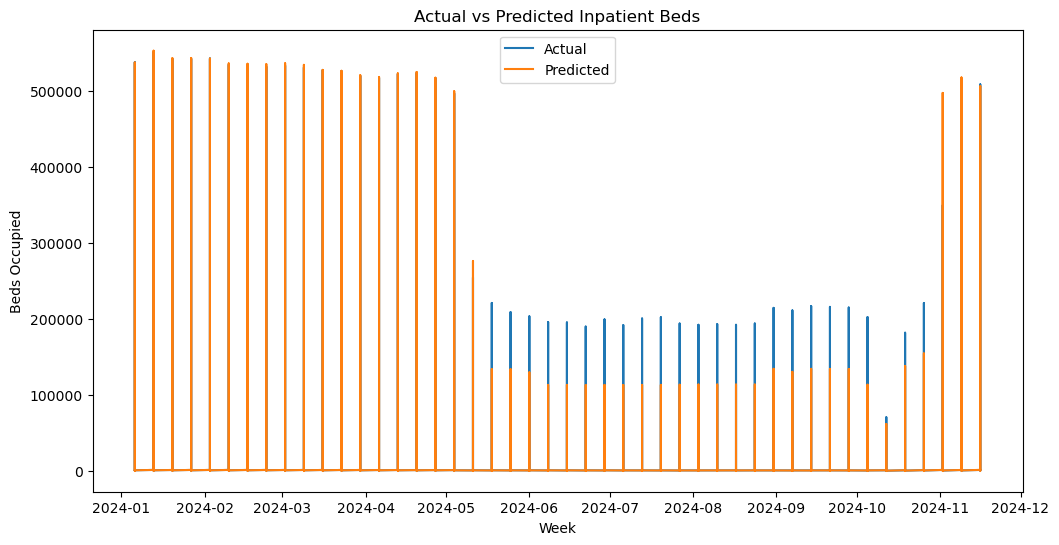

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.xlabel('Week')
plt.ylabel('Beds Occupied')
plt.title('Actual vs Predicted Inpatient Beds')
plt.legend()
plt.show()

In [125]:
#Evaluate Model Performance
#Goal: Quantify how well your predictions match actual admissions.
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")

MSE: 73642640.91, RMSE: 8581.53, MAE: 1016.68


Top 5 weeks with largest prediction errors:
                  Actual  Predicted   Error
week_ending_date                           
2024-11-02        1014.0    1033.60  -19.60
2024-11-02        5517.0    5649.74 -132.74
2024-11-02        3731.0    3992.73 -261.73
2024-11-02          80.0      72.51    7.49
2024-11-02        6984.0    6343.22  640.78
...                  ...        ...     ...
2024-05-18         134.0     142.70   -8.70
2024-05-18        9535.0    9408.97  126.03
2024-05-18        4598.0    4648.94  -50.94
2024-05-18           7.0      42.08  -35.08
2024-05-18         605.0     536.01   68.99

[242 rows x 3 columns]

Weeks with predicted high demand:
                    Actual  Predicted    Error
week_ending_date                              
2024-01-06         48518.0   48482.23    35.77
2024-01-06         42465.0   42563.31   -98.31
2024-01-06         16730.0   17062.18  -332.18
2024-01-06         20043.0   20151.43  -108.43
2024-01-06         17220.0   17150.91    69

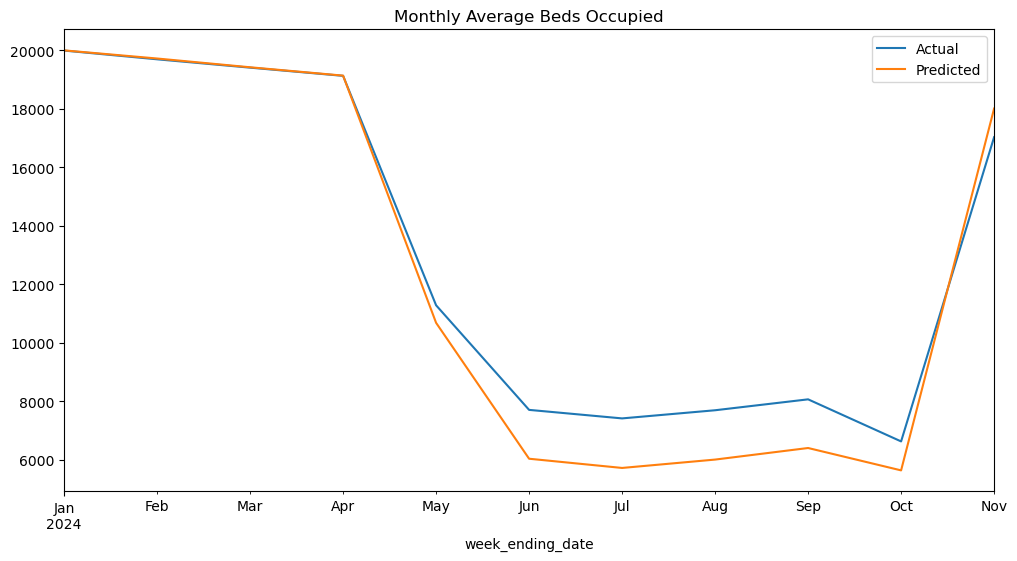

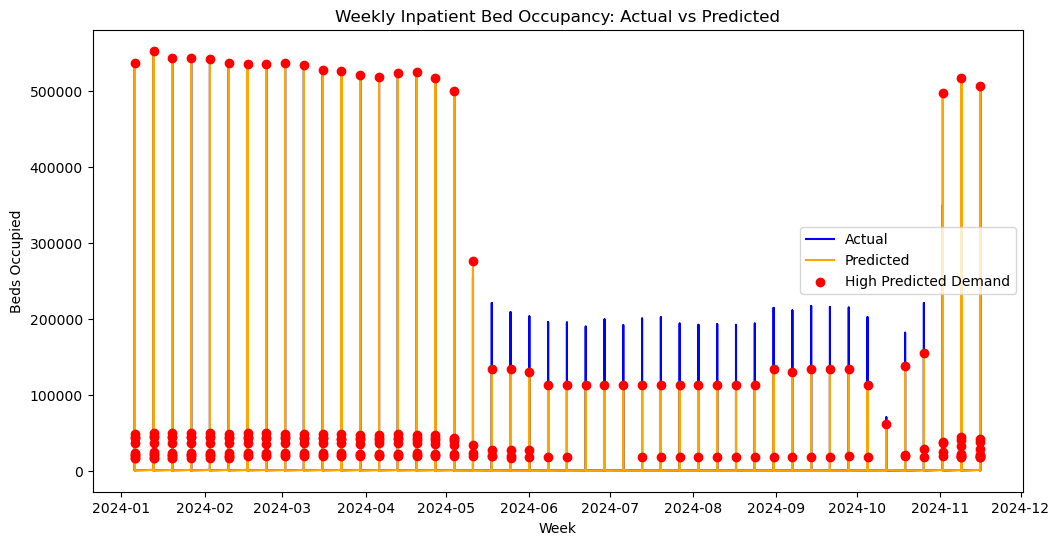

In [121]:
# Step 1: Create results table
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
results['Error'] = results['Actual'] - results['Predicted']
results.head(10)  # Show first 10 weeks

# Step 2: Monthly trends
monthly_results = results.resample('ME').mean()  # Only works if index is datetime
monthly_results[['Actual', 'Predicted']].plot(figsize=(12,6), title='Monthly Average Beds Occupied')

# Step 3: Identify top errors
top_errors = results['Error'].abs().sort_values(ascending=False).head(5)
print("Top 5 weeks with largest prediction errors:")
print(results.loc[top_errors.index])

# Step 4: Identify high-demand weeks
high_demand_weeks = results[results['Predicted'] > results['Predicted'].quantile(0.9)]
print("\nWeeks with predicted high demand:")
print(high_demand_weeks)

# Step 5: Recommendations
print("\nRecommendations:")
print("- Increase staffing during high-demand weeks (see table above).")
print("- Allocate additional beds during peak predicted weeks.")
print("- Prepare ICU capacity and resources ahead of high-demand weeks.")
print("- Plan preventive interventions for seasonal spikes.")

# Step 6: Visualization
plt.figure(figsize=(12,6))
plt.plot(results.index, results['Actual'], label='Actual', color='blue')
plt.plot(results.index, results['Predicted'], label='Predicted', color='orange')
plt.scatter(high_demand_weeks.index, high_demand_weeks['Predicted'], 
            color='red', label='High Predicted Demand', zorder=5)
plt.xlabel('Week')
plt.ylabel('Beds Occupied')
plt.title('Weekly Inpatient Bed Occupancy: Actual vs Predicted')
plt.legend()
plt.show()

In [123]:
#Data preparation for Power BI
#Reset index so week_ending_date becomes a column
results_reset = results.reset_index().rename(columns={'index': 'week_ending_date'})

# Add HighDemand flag
results_reset['HighDemand'] = results_reset['Predicted'] > results_reset['Predicted'].quantile(0.9)

# Add Year and Month columns
results_reset['Year'] = results_reset['week_ending_date'].dt.year
results_reset['Month'] = results_reset['week_ending_date'].dt.month

# Export to CSV for Power BI
results_reset.to_csv('hospital_beds_forecast_for_powerbi.csv', index=False)

In [124]:
import os
os.getcwd()

'/Users/temitope/My projects/Weekly_hospital_respiratory_data_2020_2024'